Sel 1 (Code): Import Library & Setup

In [1]:
import requests
import pandas as pd
import re
import nltk
import demoji
import numpy as np
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import TruncatedSVD, PCA

# 1. Download stopwords NLTK
nltk.download('stopwords', quiet=True)

True

Sel 2 (Code): Pengambilan Data & Preprocessing

In [2]:
# 2. Ambil data dari API DummyJSON
url = "https://dummyjson.com/products?limit=5"
response = requests.get(url)
produk_list = response.json()['products']

# Memasukkan ke DataFrame
df = pd.DataFrame(produk_list)[['title', 'description']]

# 3. Preprocessing Teks
stop_words = set(stopwords.words('english'))
snowball = SnowballStemmer('english')

def bersihkan_teks(teks):
    teks = demoji.replace(teks, '')
    teks = teks.lower()
    teks = re.sub(r'[^a-z\s]', '', teks)
    kata_kata = teks.split()
    kata_bersih = [snowball.stem(k) for k in kata_kata if k not in stop_words]
    return " ".join(kata_bersih)

df['clean_text'] = df['description'].apply(bersihkan_teks)
df.head() # Menampilkan pratinjau hasil pembersihan

,title,description,clean_text
0,Essence Mascara Lash Princess,The Essence Mascara Lash Princess is a popular...,essenc mascara lash princess popular mascara k...
1,Eyeshadow Palette with Mirror,The Eyeshadow Palette with Mirror offers a ver...,eyeshadow palett mirror offer versatil rang ey...
2,Powder Canister,The Powder Canister is a finely milled setting...,powder canist fine mill set powder design set ...
3,Red Lipstick,The Red Lipstick is a classic and bold choice ...,red lipstick classic bold choic ad pop color l...
4,Red Nail Polish,The Red Nail Polish offers a rich and glossy r...,red nail polish offer rich glossi red hue vibr...


Sel 3 (Code): One-Hot Encoding

In [3]:
# ==========================================
# 1. ONE-HOT ENCODING
# ==========================================
ohe = OneHotEncoder(sparse_output=False)
ohe_matrix = ohe.fit_transform(df[['clean_text']])
df_ohe = pd.DataFrame(ohe_matrix, columns=ohe.get_feature_names_out(['clean_text']))

print("=== 1. ONE-HOT ENCODING MATRIX ===")
df_ohe

=== 1. ONE-HOT ENCODING MATRIX ===


,clean_text_essenc mascara lash princess popular mascara known volum lengthen effect achiev dramat lash longlast crueltyfre formula,clean_text_eyeshadow palett mirror offer versatil rang eyeshadow shade creat stun eye look builtin mirror conveni onthego makeup applic,clean_text_powder canist fine mill set powder design set makeup control shine lightweight transluc formula provid smooth matt finish,clean_text_red lipstick classic bold choic ad pop color lip creami pigment formula provid vibrant longlast finish,clean_text_red nail polish offer rich glossi red hue vibrant polish nail quickdri formula provid salonqu finish home
0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,1.0


Sel 4 (Code): Count Vectorizer

In [4]:
# ==========================================
# 2. COUNT VECTORIZER (Bag of Words)
# ==========================================
c_vectorizer = CountVectorizer()
count_matrix = c_vectorizer.fit_transform(df['clean_text'])
df_count = pd.DataFrame(count_matrix.toarray(), columns=c_vectorizer.get_feature_names_out())

print("=== 2. COUNT VECTORIZER (BAG OF WORDS) ===")
df_count

=== 2. COUNT VECTORIZER (BAG OF WORDS) ===


,achiev,ad,applic,bold,builtin,canist,choic,classic,color,control,...,salonqu,set,shade,shine,smooth,stun,transluc,versatil,vibrant,volum
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,1,0,1,0,0,0,0,0,...,0,0,1,0,0,1,0,1,0,0
2,0,0,0,0,0,1,0,0,0,1,...,0,2,0,1,1,0,1,0,0,0
3,0,1,0,1,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0


Sel 5 (Code): TF-IDF Vectorizer

In [5]:
# ==========================================
# 3. TF-IDF VECTORIZER
# ==========================================
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['clean_text'])
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

print("=== 3. TF-IDF MATRIX ===")
df_tfidf.round(4)

=== 3. TF-IDF MATRIX ===


,achiev,ad,applic,bold,builtin,canist,choic,classic,color,control,...,salonqu,set,shade,shine,smooth,stun,transluc,versatil,vibrant,volum
0,0.2296,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2296
1,0.0000,0.0000,0.2167,0.0000,0.2167,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.2167,0.0000,0.0000,0.2167,0.0000,0.2167,0.0000,0.0000
2,0.0000,0.0000,0.0000,0.0000,0.0000,0.2244,0.0000,0.0000,0.0000,0.2244,...,0.0000,0.4487,0.0000,0.2244,0.2244,0.0000,0.2244,0.0000,0.0000,0.0000
3,0.0000,0.2756,0.0000,0.2756,0.0000,0.0000,0.2756,0.2756,0.2756,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2223,0.0000
4,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.2287,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1845,0.0000


Sel 6 (Code): Word Embedding

In [6]:
# ==========================================
# 4. WORD EMBEDDING (Word2Vec / LSA Equivalent via SVD)
# ==========================================
# Membuat Co-occurrence Matrix untuk representasi kata (Word Embedding)
vocab = tfidf_vectorizer.get_feature_names_out()
# Transpose matrix TF-IDF untuk mendapatkan vektor berbasis kata (bukan dokumen)
word_vectors_matrix = tfidf_matrix.T.toarray()

print("=== 4. WORD EMBEDDING MODEL (Word Matrix) ===")
print(f"Jumlah kata unik: {len(vocab)}")
print(f"Sampel vektor kata '{vocab[0]}':\n", word_vectors_matrix[0])

=== 4. WORD EMBEDDING MODEL (Word Matrix) ===
Jumlah kata unik: 64
Sampel vektor kata 'achiev':
 [0.22960726 0.         0.         0.         0.        ]


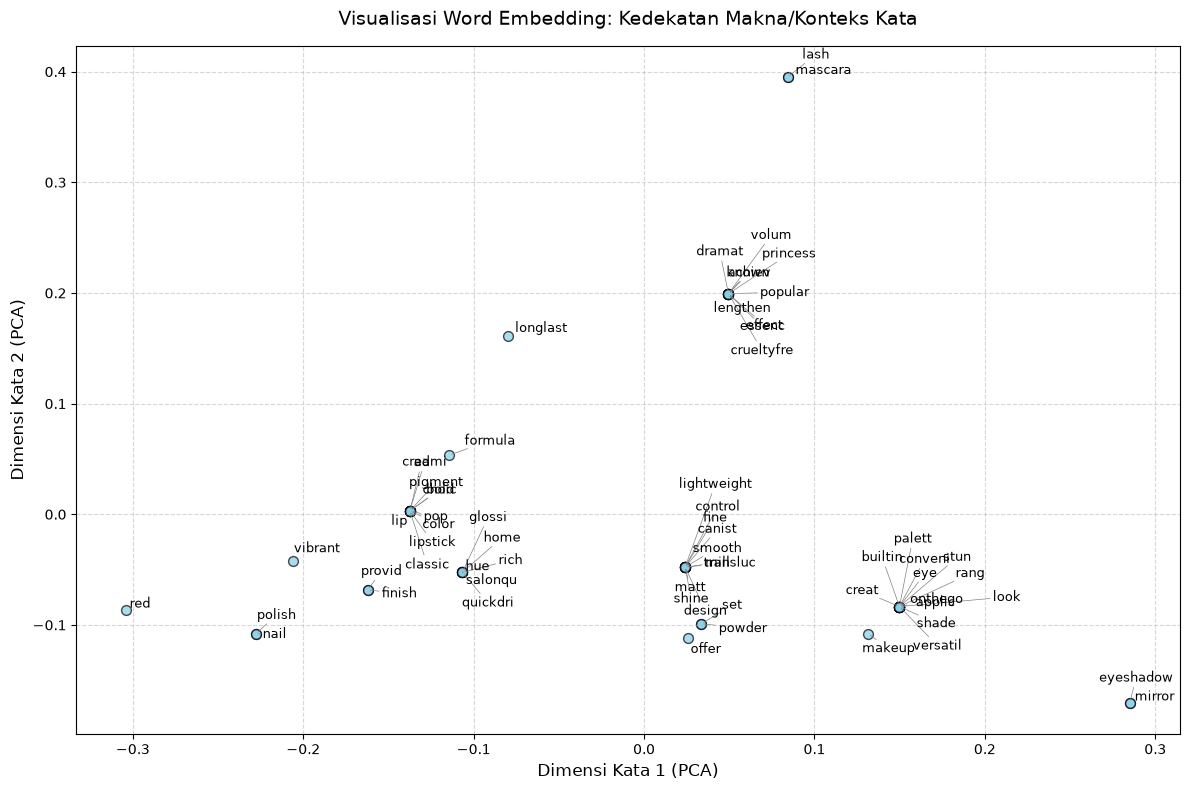

In [8]:
from adjustText import adjust_text

# Mereduksi vektor kata menjadi 2 dimensi
pca_word = PCA(n_components=2)
word_vectors_2d = pca_word.fit_transform(word_vectors_matrix)

plt.figure(figsize=(12, 8))

# Membuat scatter plot titik-titik kata
plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1], 
            color='skyblue', edgecolor='black', s=50, alpha=0.7)

# Simpan semua objek teks ke dalam list (tidak langsung di-annotate)
texts = []
for i, word in enumerate(vocab):
    texts.append(plt.text(word_vectors_2d[i, 0], word_vectors_2d[i, 1], word, fontsize=9))

# Rapikan teks secara otomatis agar tidak saling tindih
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5))

plt.title("Visualisasi Word Embedding: Kedekatan Makna/Konteks Kata", fontsize=14, pad=15)
plt.xlabel("Dimensi Kata 1 (PCA)", fontsize=12)
plt.ylabel("Dimensi Kata 2 (PCA)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Sel 7 (Code): Visualisasi Kata Paling Sering Muncul (Bar Chart)

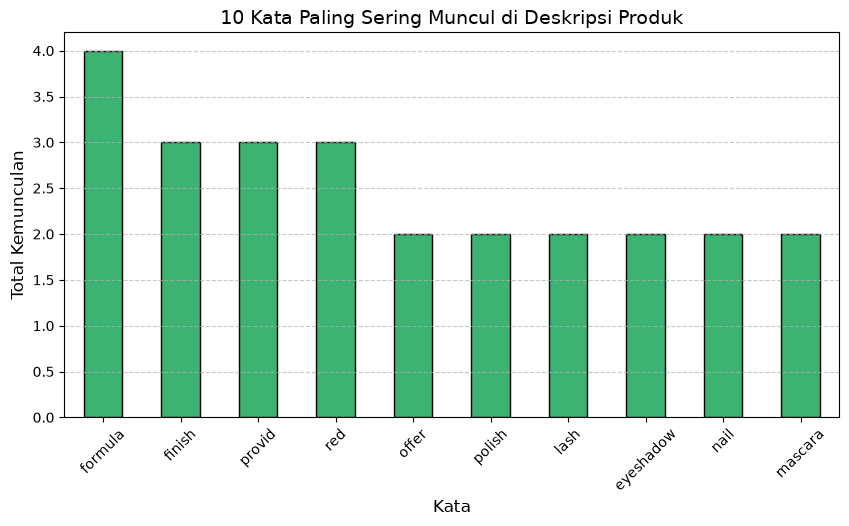

In [9]:
# Menjumlahkan kemunculan setiap kata dari semua produk
word_counts = df_count.sum(axis=0).sort_values(ascending=False)

# Mengambil 10 kata teratas
top_words = word_counts.head(10)

plt.figure(figsize=(10, 5))
top_words.plot(kind='bar', color='mediumseagreen', edgecolor='black')

plt.title("10 Kata Paling Sering Muncul di Deskripsi Produk", fontsize=14)
plt.xlabel("Kata", fontsize=12)
plt.ylabel("Total Kemunculan", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Sel 8 (Code): Fastext visualization

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from adjustText import adjust_text
from gensim.models import FastText

# 1. Menyiapkan data teks ke format yang diminta Gensim (List of Lists of words)
kalimat_token = [teks.split() for teks in df['clean_text']]

# 2. Melatih model FastText
# Karena data hanya 5 produk, kita gunakan min_count=1 agar tidak ada kata yang dibuang
ft_model = FastText(sentences=kalimat_token, vector_size=100, window=3, min_count=1, epochs=50)

# 3. Ekstraksi daftar kata (vocabulary) dan nilai vektor FastText-nya
vocab_ft = list(ft_model.wv.key_to_index.keys())
vektor_ft = ft_model.wv[vocab_ft]

# 4. Mereduksi dimensi 100D dari FastText menjadi 2D menggunakan PCA
pca_ft = PCA(n_components=2)
vektor_2d_ft = pca_ft.fit_transform(vektor_ft)

# 5. Visualisasi Scatter Plot
plt.figure(figsize=(14, 9))

# Menambahkan sedikit nilai acak (jitter) untuk keamanan ekstra
np.random.seed(42)
jitter = np.random.normal(0, 0.005, vektor_2d_ft.shape)
vektor_2d_ft_jitter = vektor_2d_ft + jitter

# Menggambar titik-titik kata
plt.scatter(vektor_2d_ft_jitter[:, 0], vektor_2d_ft_jitter[:, 1], 
            color='mediumpurple', edgecolor='black', s=50, alpha=0.7)

# Mengumpulkan objek teks
texts_ft = []
for i, word in enumerate(vocab_ft):
    texts_ft.append(plt.text(vektor_2d_ft_jitter[i, 0], vektor_2d_ft_jitter[i, 1], word, fontsize=9))

# Merapikan teks secara otomatis
adjust_text(texts_ft, 
            force_text=(1.5, 2.0), 
            force_points=(1.5, 2.0),
            expand_points=(1.5, 1.5),
            arrowprops=dict(arrowstyle="-", color='gray', lw=0.5, alpha=0.6))

plt.title("Visualisasi FastText Embedding: Jaringan Konteks Sub-kata", fontsize=14, pad=15)
plt.xlabel("Dimensi 1 (PCA)", fontsize=12)
plt.ylabel("Dimensi 2 (PCA)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'gensim'